# Synthetic Banding Experiment - Evaluation

In [1]:
import sys
sys.path.insert(0, '../..')
import math
import numpy as np
import matplotlib.pyplot as plt 
import mssfp
import deepssfp
from deepssfp import dataloader, view, recon, dataformatter, deepssfp, models, plotlib

In [2]:
mode = 'SyntheticBanding'
HEIGHT = 128
WIDTH = 128
CHANNELS_IN = 8
CHANNELS_OUT = 8
data_shape = (HEIGHT, WIDTH, CHANNELS_IN, CHANNELS_OUT) 
model = deepssfp.load_model(mode, data_shape=data_shape)

Loading model weights from saved_models\deepssfp_syntheticbanding


In [3]:
dataset = mssfp.generate_ssfp_dataset(N=128, npcs=8, f=500, alpha=np.deg2rad(60), sigma=0.0001, data_indices=[(None, None), (120,180)], rotate=True, deform=True)
data = dataset['M']
mode = 'SyntheticBanding'
ds = deepssfp.dataset.Dataset(mode, input_data=data)

Generating 3d phantom:(1200, 434, 362)


  0%|          | 0/1200 [00:00<?, ?it/s]c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:64: RuntimeWarning: divide by zero encountered in divide
  E1 = np.where(T1 > 0, np.exp(-TR / T1), 0)
c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:65: RuntimeWarning: divide by zero encountered in divide
  E2 = np.where(T2 > 0, np.exp(-TR / T2), 0)
c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:91: RuntimeWarning: divide by zero encountered in divide
  T2_decay = np.where(T2 > 0, np.exp(-TE / T2), 0)
100%|██████████| 1200/1200 [00:22<00:00, 53.02it/s]


Generating 3d phantom:(1, 434, 362)


100%|██████████| 1/1 [00:00<00:00, 52.63it/s]


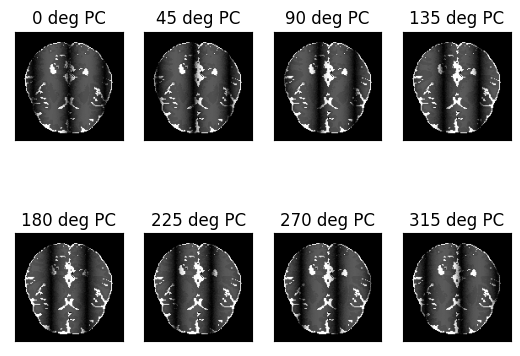

(1, 128, 128, 8)

In [4]:
TR: float = 3e-3
TE: float = 3e-3 / 2
alpha = np.deg2rad(60)
dataset_val = mssfp.generate_ssfp_dataset(N=128, npcs=8, f=500, alpha=alpha, sigma=0, data_indices=[1, 150])
M = dataset_val['M']
fieldmap = dataset_val['phantom']['offres']
T1 = dataset_val['phantom']['t1_map']
T2 = dataset_val['phantom']['t2_map']
mssfp.plot_dataset(M)
M.shape

X: (1, 128, 128, 8)
Y: (1, 128, 128, 8)
Y: (1, 128, 128, 4)


../..\deepssfp\dataformatter.py:65: ComplexWarning: Casting complex values to real discards the imaginary part
  out[:,:,:,ii] = x[:,:,:,2*ii] + 1j * x[:,:,:,2*ii+1]


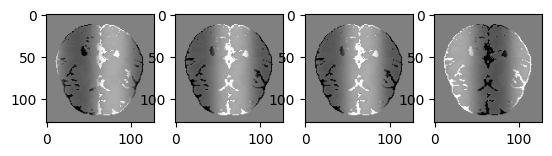

In [9]:
x_val = ds.transform(M, 'input')
print(f'X: {x_val.shape}')

y_pred = model.predict(x_val)
print(f'Y: {y_pred.shape}')

Y_pred = ds.transform(y_pred, 'output')
print(f'Y: {Y_pred.shape}')

plt.figure()
plt.subplot(1,4,1)
plt.imshow(Y_pred[0,:,:,0])
plt.subplot(1,4,2)
plt.imshow(Y_pred[0,:,:,1])
plt.subplot(1,4,3)
plt.imshow(y_pred[0,:,:,2])            
plt.subplot(1,4,4)
plt.imshow(y_pred[0,:,:,3])
plt.show()
